In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        pass
        #print(os.path.join(dirname, filename))
print("DONE...")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

DONE...


In [2]:
import os
import pandas as pd
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

import random
from PIL import Image


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping,ModelCheckpoint

2025-05-24 11:22:25.903754: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748085746.169214      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748085746.254103      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# Base dataset directory
base_dir = '/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented'

# Lists to store image paths and labels
imgs = []
labels = []

# Traverse each subfolder (e.g., 'train', 'test', 'validation')
for subset in tqdm(os.listdir(base_dir), desc="Processing subsets"):
    subset_path = os.path.join(base_dir, subset)
    
    # Traverse class folders (e.g., 'MildDemented', 'NonDemented', etc.)
    for class_label in os.listdir(subset_path):
        class_path = os.path.join(subset_path, class_label)
        
        # Traverse all images in the class folder
        for image_filename in os.listdir(class_path):
            image_path = os.path.join(class_path, image_filename)
            imgs.append(image_path)
            labels.append(class_label)

# Create a DataFrame
df = pd.DataFrame({'image': imgs, 'label': labels})
df.head()

Processing subsets: 100%|██████████| 1/1 [00:00<00:00, 18.16it/s]


,image,label
0,/kaggle/input/alzheimers-multiclass-dataset-eq...,ModerateDemented
1,/kaggle/input/alzheimers-multiclass-dataset-eq...,ModerateDemented
2,/kaggle/input/alzheimers-multiclass-dataset-eq...,ModerateDemented
3,/kaggle/input/alzheimers-multiclass-dataset-eq...,ModerateDemented
4,/kaggle/input/alzheimers-multiclass-dataset-eq...,ModerateDemented


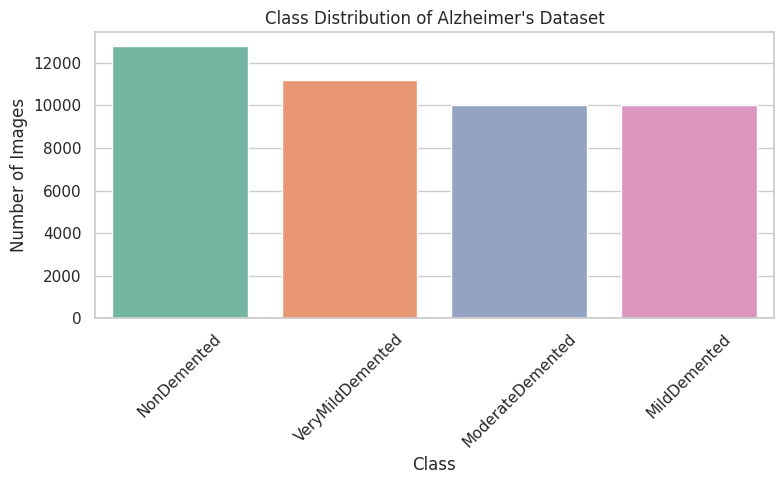

In [4]:
sns.set(style="whitegrid")

# Countplot of labels
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='Set2')

plt.title('Class Distribution of Alzheimer\'s Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

we might need to do undersampling on the dataset make all classes balanced,but lets train first and see

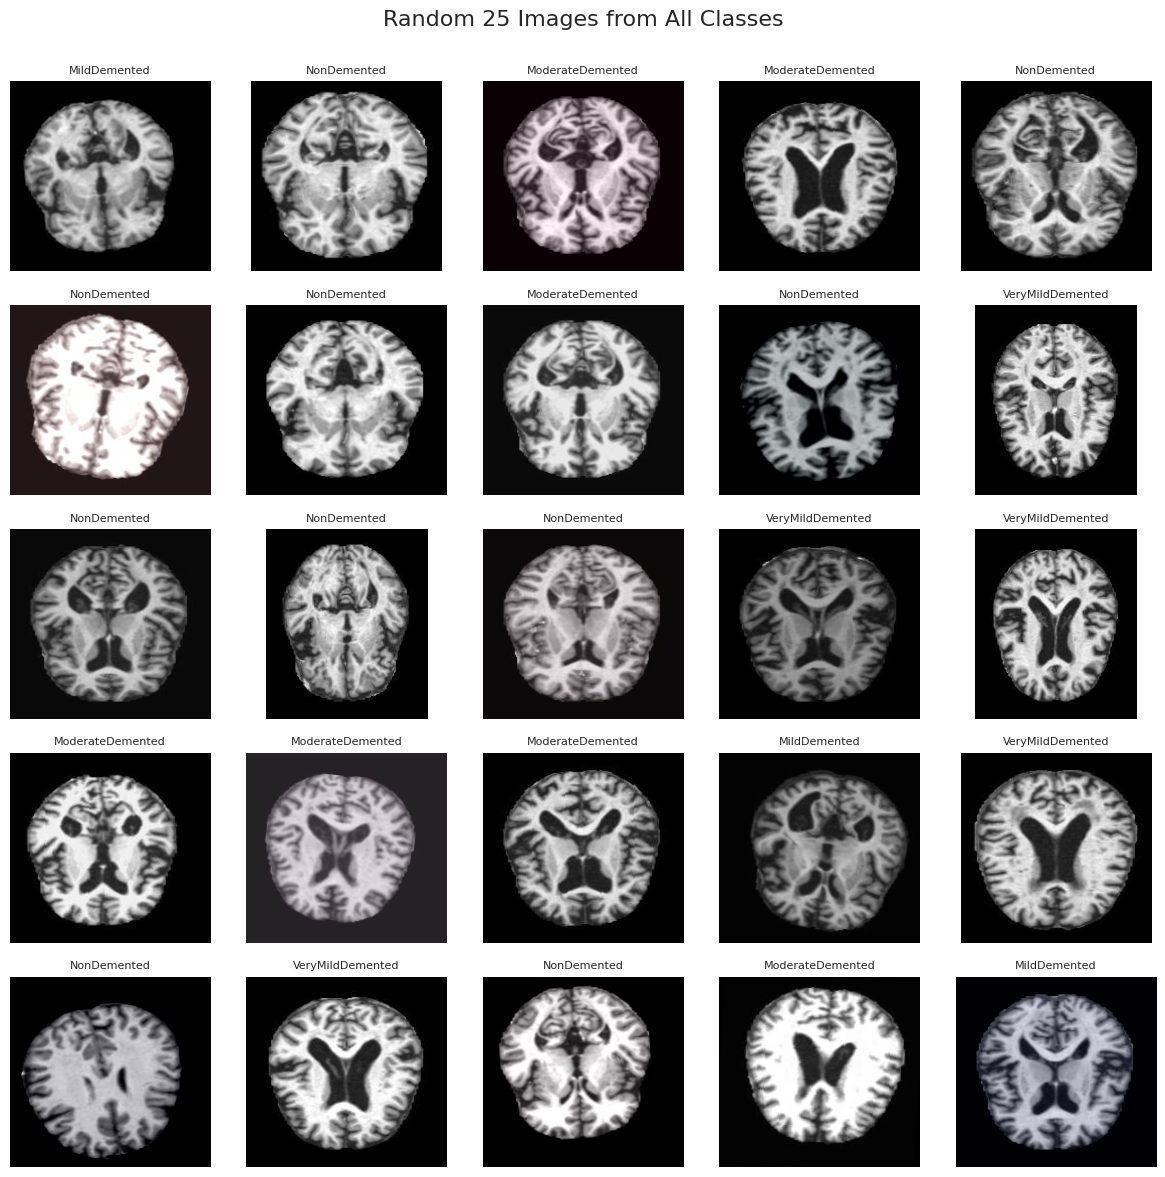

In [5]:

sample_df = df.sample(25).reset_index(drop=True)

# Set up the figure
plt.figure(figsize=(12, 12))

for i in range(25):
    img_path = sample_df.loc[i, 'image']
    label = sample_df.loc[i, 'label']
    
    # Open the image
    img = Image.open(img_path)
    
    # Plotting
    plt.subplot(5, 5, i + 1)
    plt.imshow(img, cmap='gray')  # Use cmap='gray' for grayscale images
    plt.title(label, fontsize=8)
    plt.axis('off')

plt.suptitle('Random 25 Images from All Classes', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])
class_names = label_encoder.classes_
print(class_names)

['MildDemented' 'ModerateDemented' 'NonDemented' 'VeryMildDemented']


In [7]:
df

,image,label,label_encoded
0,/kaggle/input/alzheimers-multiclass-dataset-eq...,ModerateDemented,1
1,/kaggle/input/alzheimers-multiclass-dataset-eq...,ModerateDemented,1
2,/kaggle/input/alzheimers-multiclass-dataset-eq...,ModerateDemented,1
3,/kaggle/input/alzheimers-multiclass-dataset-eq...,ModerateDemented,1
4,/kaggle/input/alzheimers-multiclass-dataset-eq...,ModerateDemented,1
...,...,...,...
43995,/kaggle/input/alzheimers-multiclass-dataset-eq...,MildDemented,0
43996,/kaggle/input/alzheimers-multiclass-dataset-eq...,MildDemented,0
43997,/kaggle/input/alzheimers-multiclass-dataset-eq...,MildDemented,0
43998,/kaggle/input/alzheimers-multiclass-dataset-eq...,MildDemented,0


In [8]:
# First split: train (70%) and temp (30%)
train_df, test_val_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['label_encoded'],
    random_state=42
)

# Second split: validation (15%) and test (15%) from temp
val_df, test_df = train_test_split(
    test_val_df,
    test_size=0.5,
    stratify=test_val_df['label_encoded'],
    random_state=42
)

# Display sizes
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")



Train size: 30800
Validation size: 6600
Test size: 6600


In [9]:
train_df.shape,val_df.shape

((30800, 3), (6600, 3))

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import preprocess_input

#the labels are one hot encoded.
# Define generators
train_datagen = ImageDataGenerator(
    preprocessing_function= preprocess_input,
    rescale=1./255,
    #rotation_range=10,
    #zoom_range=0.1,
    horizontal_flip=True
)
image_size = (224,224)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Flow from DataFrame
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image',
    y_col='label',
    target_size=image_size,
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image',
    y_col='label',
    target_size=image_size,
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image',
    y_col='label',
    target_size=image_size,
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)


Found 30800 validated image filenames belonging to 4 classes.
Found 6600 validated image filenames belonging to 4 classes.
Found 6600 validated image filenames belonging to 4 classes.


In [81]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
def Metrics_report(model):
    score_acc= model.evaluate(test_generator)
    print('Test Loss =', score_acc[0])
    print('Test Accuracy =', score_acc[1])

    y_test =test_generator.classes
    preds = model.predict(test_generator)
    y_pred = np.argmax(preds,axis=1)
    y_test = np.ravel(y_test)
    y_pred = np.ravel(y_pred)

    cls_num=list(train_generator.class_indices.keys())
    
    conf_mat = confusion_matrix(y_test,y_pred)
    CM_perc = np.round(conf_mat.astype('float') / conf_mat.sum(axis=1)[:, np.newaxis],2)
    sns.heatmap(CM_perc,fmt='g',center = True,cbar=False,annot=True,cmap='Blues',xticklabels=cls_num, yticklabels=cls_num)

    #classification report
    ClassificationReport = classification_report(y_test,y_pred,target_names=cls_num)
    print('Classification Report is : ', ClassificationReport)
    
    return conf_mat


In [12]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Accuracy Over Epochs')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Loss Over Epochs')

    plt.show()

In [13]:
from tensorflow.keras import layers, models, regularizers

#hand stiched model

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),

    # Replace Flatten with Global Average Pooling
    layers.GlobalAveragePooling2D(),

    # Dense layer with regularization and dropout
    layers.Dense(256, activation='relu', kernel_initializer='he_normal',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),

    # Output layer (4 classes)
    layers.Dense(4, activation='softmax')
])


I0000 00:00:1748085787.026824      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # or categorical if labels are one-hot
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_2 (ReLU)                       │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_3 (ReLU)                       │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │              

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Save the best model only
checkpoint_cb = ModelCheckpoint("best_model.h5", save_best_only=True)

# Stop training early if no improvement
earlystop_cb = EarlyStopping(patience=10, restore_best_weights=True)

# Train with callbacks
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[checkpoint_cb, earlystop_cb]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1748085793.461481     100 service.cc:148] XLA service 0x7f1d580026b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748085793.462845     100 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1748085794.008103     100 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/963 ━━━━━━━━━━━━━━━━━━━━ 1:14 77ms/step - accuracy: 0.2101 - loss: 2.5505  

I0000 00:00:1748085799.616787     100 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


963/963 ━━━━━━━━━━━━━━━━━━━━ 161s 156ms/step - accuracy: 0.4144 - loss: 1.5737 - val_accuracy: 0.2909 - val_loss: 12.1593
Epoch 2/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 76s 79ms/step - accuracy: 0.5525 - loss: 1.0834 - val_accuracy: 0.2909 - val_loss: 12.7300
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 80s 83ms/step - accuracy: 0.6197 - loss: 0.8624 - val_accuracy: 0.2909 - val_loss: 15.7276
Epoch 4/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 81s 84ms/step - accuracy: 0.6495 - loss: 0.7819 - val_accuracy: 0.2909 - val_loss: 12.1765
Epoch 5/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 74s 77ms/step - accuracy: 0.6635 - loss: 0.7338 - val_accuracy: 0.3014 - val_loss: 3.7620
Epoch 6/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 73s 76ms/step - accuracy: 0.6778 - loss: 0.7061 - val_accuracy: 0.2909 - val_loss: 7.1437
Epoch 7/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 73s 76ms/step - accuracy: 0.6997 - loss: 0.6733 - val_accuracy: 0.2911 - val_loss: 5.7319
Epoch 8/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 78s 81ms/step - accuracy: 0.7136 - loss: 0.6422 - val_a

207/207 ━━━━━━━━━━━━━━━━━━━━ 41s 197ms/step - accuracy: 0.7236 - loss: 0.8654
Val Loss = 0.8516656160354614
Val Accuracy = 0.7269697189331055
207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step
Classification Report is :                    precision    recall  f1-score   support

    MildDemented       0.57      0.92      0.70      1500
ModerateDemented       1.00      0.96      0.98      1500
     NonDemented       0.72      0.75      0.73      1920
VeryMildDemented       0.75      0.32      0.45      1680

        accuracy                           0.73      6600
       macro avg       0.76      0.74      0.72      6600
    weighted avg       0.76      0.73      0.71      6600



/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


array([[1387,    0,   95,   18],
       [  13, 1439,   47,    1],
       [ 327,    0, 1438,  155],
       [ 723,    0,  423,  534]])

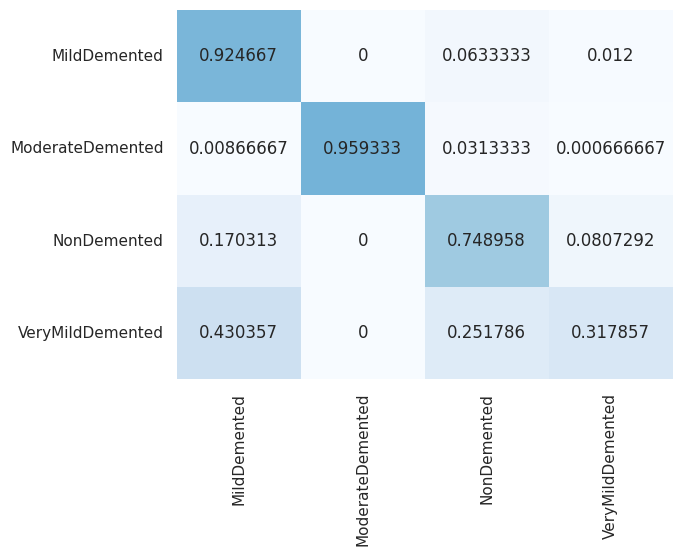

In [16]:
conf_mat = Metrics_report(model)
conf_mat

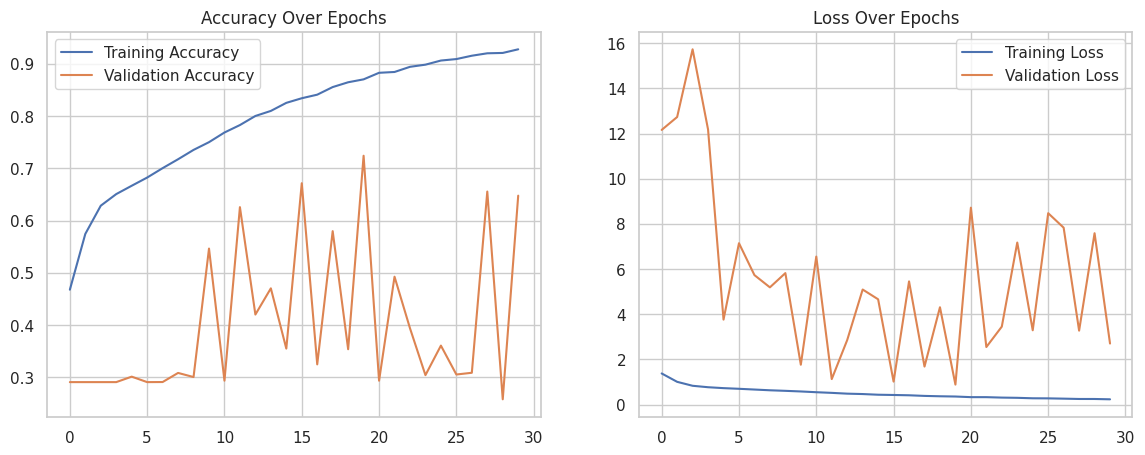

In [17]:
plot_history(history)

In [18]:
#this for the just the sccan model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import preprocess_input

#the labels are one hot encoded.
# Define generators
train_datagen = ImageDataGenerator(
    #preprocessing_function= preprocess_input,
    rescale=1./255,
    #rotation_range=10,
    #zoom_range=0.1,
    horizontal_flip=True
)
image_size = (224,224)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Flow from DataFrame
train_generator_SCCAN = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image',
    y_col='label',
    target_size=image_size,
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)

val_generator_SCCAN = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image',
    y_col='label',
    target_size=image_size,
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

test_generator_SCCAN = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image',
    y_col='label',
    target_size=image_size,
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)


Found 30800 validated image filenames belonging to 4 classes.
Found 6600 validated image filenames belonging to 4 classes.
Found 6600 validated image filenames belonging to 4 classes.


In [21]:
# SCCAN (Stacked CNN with Channel Attention Network)
def channel_attention(input_feature, ratio=8):
    channel = input_feature.shape[-1]
    shared_layer_one = layers.Dense(channel // ratio,
                                    activation='relu',
                                    kernel_initializer='he_normal',
                                    use_bias=True,
                                    bias_initializer='zeros')
    shared_layer_two = layers.Dense(channel,
                                    kernel_initializer='he_normal',
                                    use_bias=True,
                                    bias_initializer='zeros')

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1,1,channel))(avg_pool)
    avg_pool = shared_layer_one(avg_pool)
    avg_pool = shared_layer_two(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1,1,channel))(max_pool)
    max_pool = shared_layer_one(max_pool)
    max_pool = shared_layer_two(max_pool)

    cbam_feature = layers.Add()([avg_pool, max_pool])
    cbam_feature = layers.Activation('sigmoid')(cbam_feature)

    return layers.Multiply()([input_feature, cbam_feature])

def build_sccan(input_shape=(224, 224, 3), num_classes=4):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = channel_attention(x)

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = channel_attention(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = channel_attention(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

# Instantiate and compile the model
model = build_sccan()
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 224, 224, 32)   │            896 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_7     │ (None, 224, 224, 32)   │            128 │ conv2d_7[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_7           │ (None, 112, 112, 32)   │              0 │ batch_normalization_7… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 32)             │              0 │ max_pooling2d_7[0][0]  │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling2d_3    │ (None, 32)             │              0 │ max_pooling2d_7[0][0]  │
│ (GlobalMaxPooling2D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_6 (Reshape)       │ (None, 1, 1, 32)       │              0 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_7 (Reshape)       │ (None, 1, 1, 32)       │              0 │ global_max_pooling2d_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 1, 1, 4)        │            132 │ reshape_6[0][0],       │
│                           │                        │                │ reshape_7[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 1, 1, 32)       │            160 │ dense_10[0][0],        │
│                           │                        │                │ dense_10[1][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_3 (Add)               │ (None, 1, 1, 32)       │              0 │ dense_11[0][0],        │
│                           │                        │                │ dense_11[1][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 1, 1, 32)       │              0 │ add_3[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_3 (Multiply)     │ (None, 112, 112, 32)   │              0 │ max_pooling2d_7[0][0], │
│                           │                        │                │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 112, 112, 64)   │         18,496 │ multiply_3[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_8     │ (None, 112, 112, 64)   │            256 │ conv2d_8[0][0]         │
│ (BatchNormalization) 

 Total params: 133,824 (522.75 KB)

 Trainable params: 133,376 (521.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [24]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reduce learning rate when a metric has stopped improving
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',      # What to watch
    factor=0.5,              # Reduce by half
    patience=3,              # Wait 3 epochs before reducing
    verbose=1,               # Log it
    min_lr=1e-6              # Do not go below this LR
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    lr_scheduler,
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss')
]

history = model.fit(
    train_generator_SCCAN,
    validation_data=val_generator_SCCAN,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 74s 76ms/step - accuracy: 0.9602 - loss: 0.1040 - val_accuracy: 0.9094 - val_loss: 0.2497 - learning_rate: 3.1250e-05
Epoch 2/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 72s 74ms/step - accuracy: 0.9637 - loss: 0.0952 - val_accuracy: 0.9074 - val_loss: 0.2609 - learning_rate: 3.1250e-05
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 75s 78ms/step - accuracy: 0.9642 - loss: 0.0930 - val_accuracy: 0.9065 - val_loss: 0.2602 - learning_rate: 3.1250e-05
Epoch 4/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9660 - loss: 0.0924
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
963/963 ━━━━━━━━━━━━━━━━━━━━ 69s 72ms/step - accuracy: 0.9660 - loss: 0.0924 - val_accuracy: 0.9114 - val_loss: 0.2551 - learning_rate: 3.1250e-05
Epoch 5/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 70s 72ms/step - accuracy: 0.9680 - loss: 0.0846 - val_accuracy: 0.9109 - val_loss: 0.2601 - learning_rate: 1.5625e-05
Epoch 6/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 78s 81ms/step - a

207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.9567 - loss: 0.1489
Test Loss = 0.14421051740646362
Test Accuracy = 0.9572727084159851
207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step
Classification Report is :                    precision    recall  f1-score   support

    MildDemented       0.95      0.97      0.96      1500
ModerateDemented       1.00      1.00      1.00      1500
     NonDemented       0.95      0.95      0.95      1920
VeryMildDemented       0.94      0.92      0.93      1680

        accuracy                           0.96      6600
       macro avg       0.96      0.96      0.96      6600
    weighted avg       0.96      0.96      0.96      6600



/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


array([[1452,    3,   19,   26],
       [   0, 1498,    0,    2],
       [  35,    1, 1820,   64],
       [  46,    2,   84, 1548]])

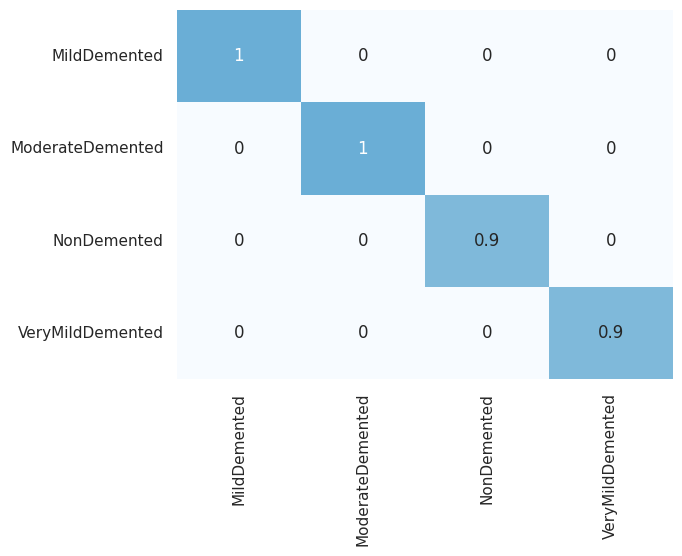

In [80]:
conf_mat = Metrics_report(model)
conf_mat

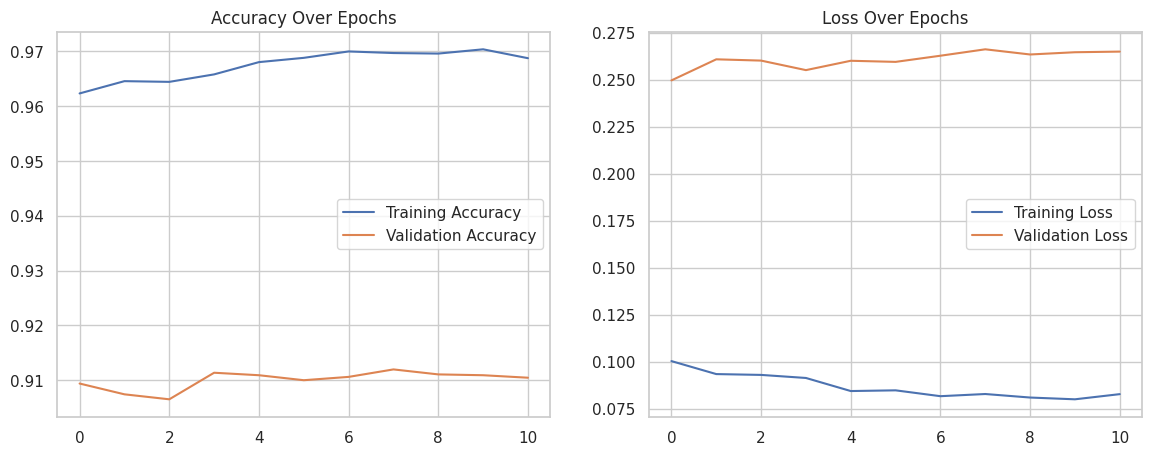

In [26]:
plot_history(history)

In [50]:
import tensorflow as tf
from tensorflow import keras

model = keras.models.Sequential()
model.add(tf.keras.applications.VGG16(input_shape=(224, 224, 3), include_top=False, pooling='avg', weights='imagenet'))
model.add(keras.layers.Flatten())
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(2048, activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(1024, activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(4, activation='softmax'))
model.layers[0].trainable = False

# Build the model with the correct input shape
model.build(input_shape=(None, 224, 224, 3))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 512)                 │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 2048)                │       1,050,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 1024)                │       2,098,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 4)                   │           4,100 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,881,924 (68.21 MB)

 Trainable params: 3,160,068 (12.05 MB)

 Non-trainable params: 14,721,856 (56.16 MB)

In [51]:
checkpointer = ModelCheckpoint("model_VGG16.keras", save_best_only=True)
early_stopper =EarlyStopping(patience=5, restore_best_weights=True)
model.compile(optimizer ='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist = model.fit(train_generator, epochs=30, validation_data=val_generator, callbacks=[checkpointer, early_stopper])

Epoch 1/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 130s 130ms/step - accuracy: 0.6876 - loss: 0.9462 - val_accuracy: 0.8029 - val_loss: 0.4917
Epoch 2/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 87s 90ms/step - accuracy: 0.8584 - loss: 0.3603 - val_accuracy: 0.8676 - val_loss: 0.3538
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 87s 90ms/step - accuracy: 0.9055 - loss: 0.2516 - val_accuracy: 0.8917 - val_loss: 0.2857
Epoch 4/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 87s 90ms/step - accuracy: 0.9278 - loss: 0.1959 - val_accuracy: 0.8902 - val_loss: 0.2882
Epoch 5/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 86s 90ms/step - accuracy: 0.9400 - loss: 0.1625 - val_accuracy: 0.9035 - val_loss: 0.2594
Epoch 6/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 88s 91ms/step - accuracy: 0.9487 - loss: 0.1403 - val_accuracy: 0.9138 - val_loss: 0.2431
Epoch 7/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 88s 91ms/step - accuracy: 0.9550 - loss: 0.1278 - val_accuracy: 0.9238 - val_loss: 0.2172
Epoch 8/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 88s 91ms/step - accuracy: 0.9612 - loss: 0.1069 

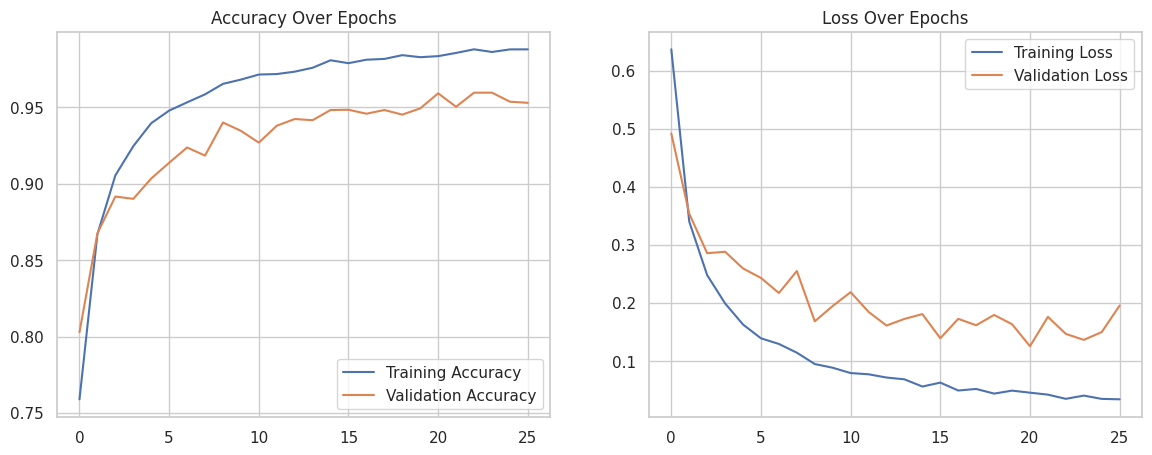

In [52]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Accuracy Over Epochs')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Loss Over Epochs')

    plt.show()

# Call it after training
plot_history(hist)

207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.9567 - loss: 0.1489
Test Loss = 0.14421051740646362
Test Accuracy = 0.9572727084159851
207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step
Classification Report is :                    precision    recall  f1-score   support

    MildDemented       0.95      0.97      0.96      1500
ModerateDemented       1.00      1.00      1.00      1500
     NonDemented       0.95      0.95      0.95      1920
VeryMildDemented       0.94      0.92      0.93      1680

        accuracy                           0.96      6600
       macro avg       0.96      0.96      0.96      6600
    weighted avg       0.96      0.96      0.96      6600



/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


array([[1452,    3,   19,   26],
       [   0, 1498,    0,    2],
       [  35,    1, 1820,   64],
       [  46,    2,   84, 1548]])

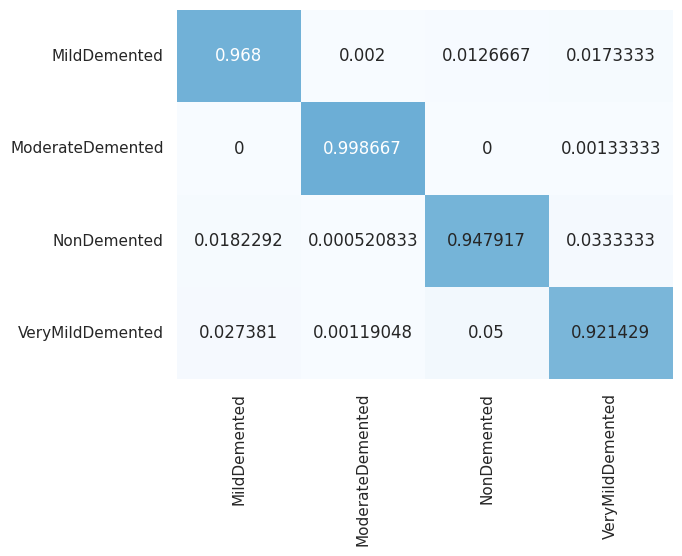

In [55]:
conf_mat = Metrics_report(model)
conf_mat

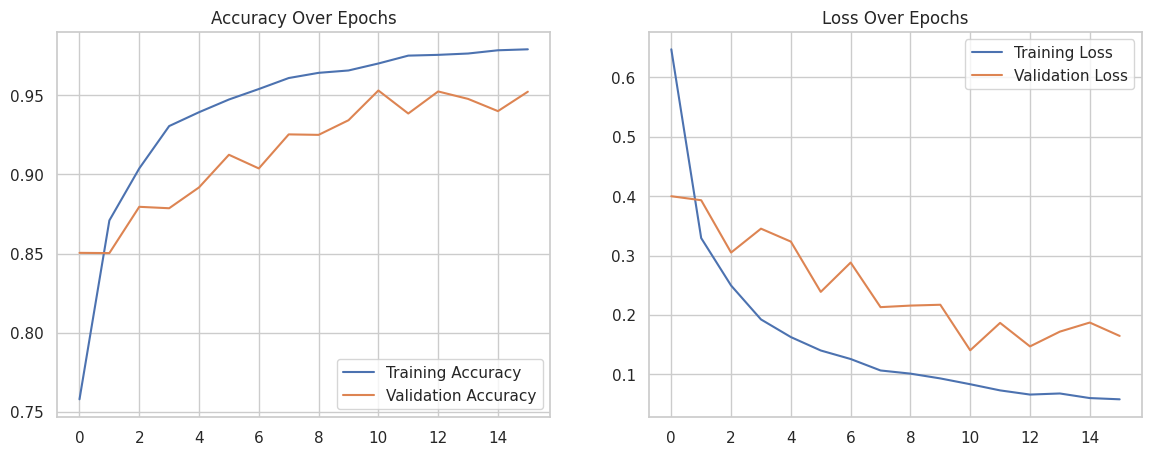

In [32]:
plot_history(hist)

In [60]:
def visualize_predictions(model, test_generator, num_images=50):
    import matplotlib.pyplot as plt
    import numpy as np
    import random

    class_names = list(test_generator.class_indices.keys())
    images = []
    labels = []

    while len(images) < num_images:
        x_batch, y_batch = next(test_generator)
        images.extend(x_batch)
        labels.extend(y_batch)
    
    images = np.array(images[:num_images])
    labels = np.array(labels[:num_images])
    
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = np.argmax(labels, axis=1)
    confidences = np.max(preds, axis=1)

    plt.figure(figsize=(18, 10))
    for i in range(num_images):
        img = images[i]
        true_label = class_names[true_labels[i]]
        pred_label = class_names[pred_labels[i]]
        confidence = confidences[i] * 100
        correct = (true_label == pred_label)
        color = 'green' if correct else 'red'
        
        plt.subplot(5, 10, i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {pred_label}  \n confidence: {confidence:.1f}%", color=color, fontsize=9)
        plt.xlabel(f"Actual: {true_label} ", fontsize=8,color = "blue")
        plt.xticks([])
        plt.yticks([])
    
    plt.tight_layout()
    plt.show()



2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 4s/step  


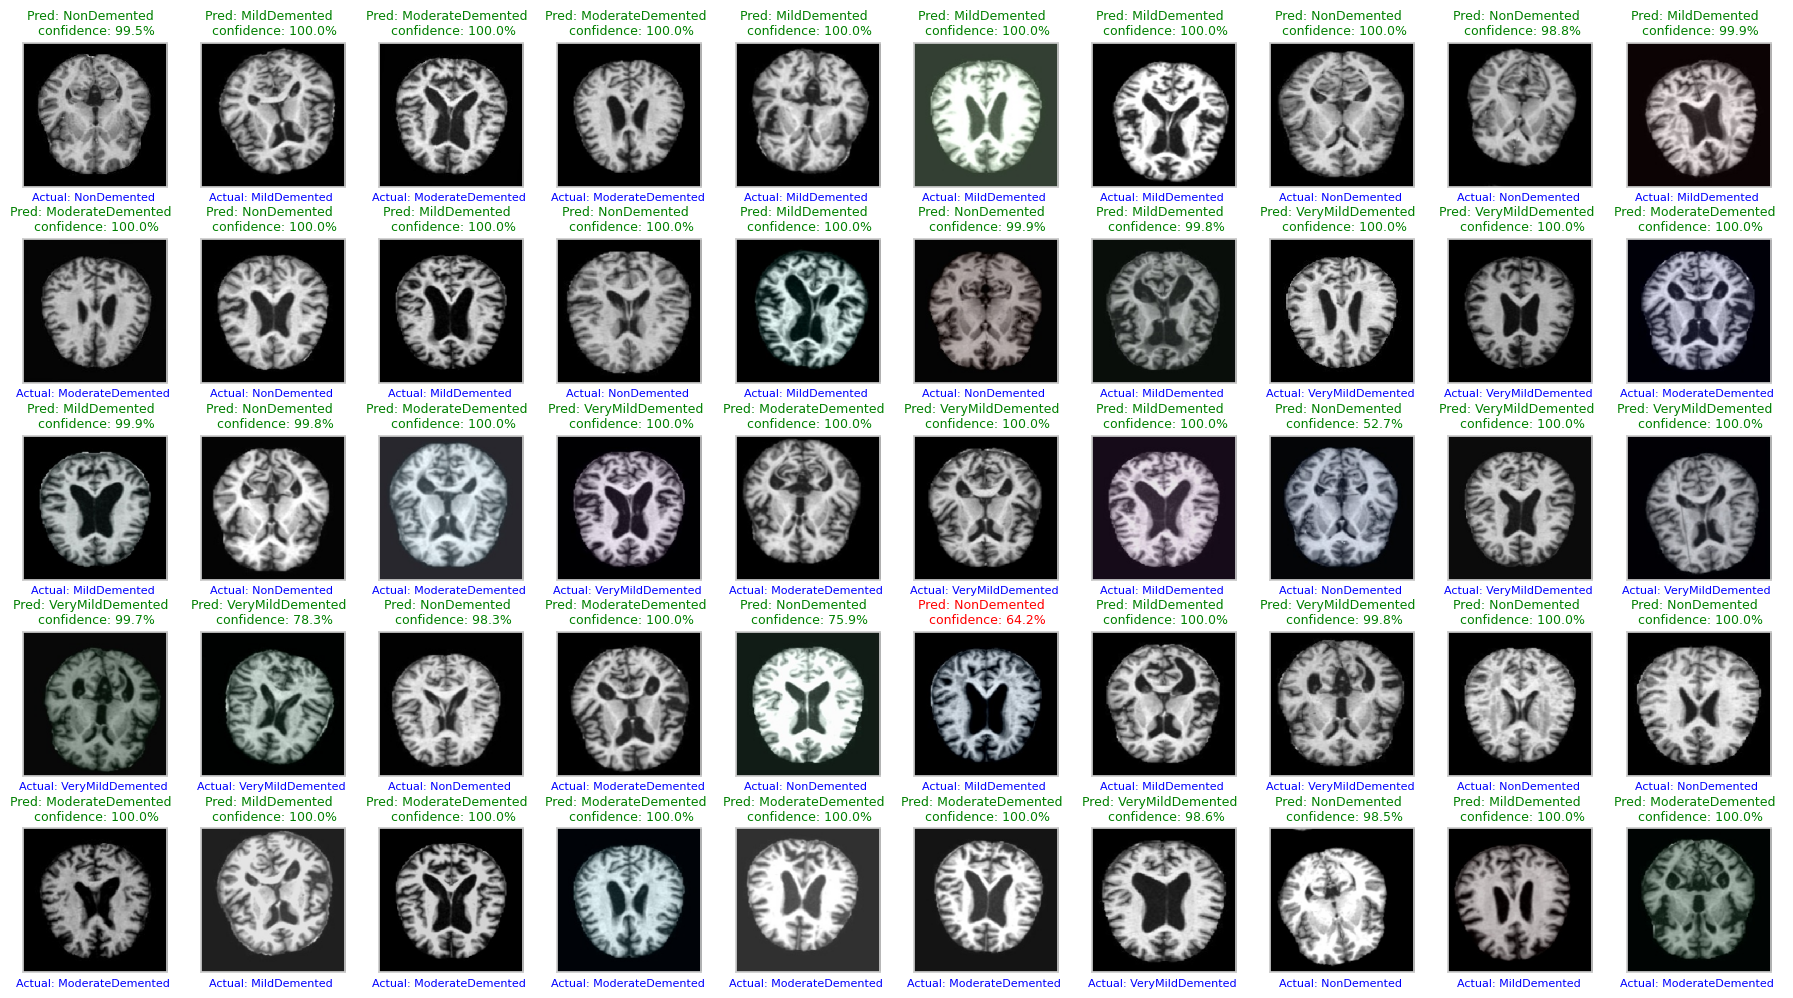

In [61]:
visualize_predictions(model, test_generator, num_images=50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


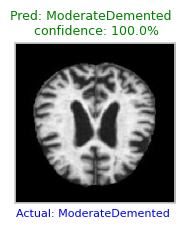

In [62]:
visualize_predictions(model, test_generator, num_images=1)

In [56]:
from tensorflow import keras
import tensorflow as tf

#model = keras.models.Sequential()
#model.add(tf.keras.applications.VGG16(input_shape=(224, 224, 3), include_top=False, pooling='avg', weights='imagenet'))
#model.add(keras.layers.Flatten())
#model.add(keras.layers.BatchNormalization())
#model.add(keras.layers.Dense(2048, activation='relu'))
#model.add(keras.layers.BatchNormalization())
#model.add(keras.layers.Dense(1024, activation='relu'))
#model.add(keras.layers.BatchNormalization())
#model.add(keras.layers.Dense(4, activation='softmax'))
#model.layers[0].trainable = False
#model.build(input_shape=(None, 224, 224, 3))
_ = model(tf.zeros((1, 224, 224, 3)))  # dummy call to build outputs


In [57]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='block5_conv3', pred_index=None):
    # Get the inner VGG16 model from the Sequential model
    vgg16_model = model.layers[0]

    # Get the convolutional layer output
    conv_layer = vgg16_model.get_layer(last_conv_layer_name)

    # Create a model from VGG16 input to the selected conv layer
    conv_model = tf.keras.models.Model(inputs=vgg16_model.input,
                                       outputs=conv_layer.output)

    # Full model: input -> conv output, then pass through full model
    inputs = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(inputs)
        # Get conv feature map
        conv_outputs = conv_model(inputs)
        # Now manually pass through the rest of the model
        x = conv_outputs
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        x = model.layers[2](x)  # BatchNorm
        x = model.layers[3](x)  # Dense
        x = model.layers[4](x)  # BatchNorm
        x = model.layers[5](x)  # Dense
        x = model.layers[6](x)  # BatchNorm
        preds = model.layers[7](x)  # Final Dense (softmax)
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)
    if grads is None:
        raise ValueError("Gradient is None. Ensure the model and inputs are correctly connected.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    # Weight the conv maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [70]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def display_gradcam(image, heatmap, alpha=0.4, predicted_label="", true_label="", confidence=0.0):
    # Resize heatmap
    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    # Overlay
    superimposed_img = heatmap_colored * alpha + (image * 255).astype(np.uint8)
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    # Plot
    plt.figure(figsize=(5, 5))
    plt.imshow(superimposed_img)
    color = "blue" if predicted_label == true_label else "red"
    plt.title(f"Predicted: {predicted_label} ({confidence:.1f}%) \n Actual: {true_label}", color=color)
    plt.xlabel(f"Actual: {true_label}")
    plt.axis("off")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


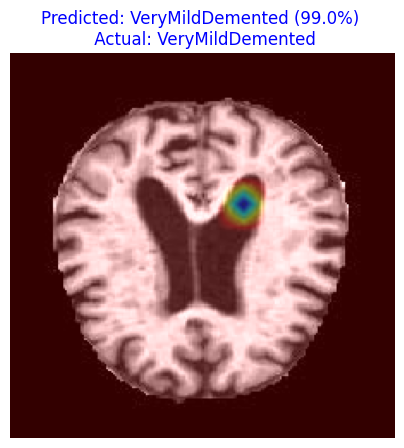

In [71]:
# Get class names
class_names = list(test_generator.class_indices.keys())

# Get one test image
images, labels = next(test_generator)
img = images[0]
true_idx = np.argmax(labels[0])
true_label = class_names[true_idx]

# Predict
preds = model.predict(img[np.newaxis, ...])[0]
pred_idx = np.argmax(preds)
pred_label = class_names[pred_idx]
confidence = preds[pred_idx] * 100

# Grad-CAM
heatmap = make_gradcam_heatmap(img[np.newaxis, ...], model, last_conv_layer_name='block5_conv3', pred_index=pred_idx)

# Show result
display_gradcam(img, heatmap, predicted_label=pred_label, true_label=true_label, confidence=confidence)
